# Team members

* ID: 0001215190 - Şimal Yücel - simal.yucel@studio.unibo.it
* ID: 0001241443 - Davide Tonelli - davide.tonelli8@studio.unibo.it
* ID: 0001230674 - Giovanni Stea - giovanni.stea@studio.unibo.it

# Assignment Module 2 — Aircraft Classification: Solution

This notebook solves the two parts of the assignment:

- **Part 1** — a convolutional network designed and trained **from scratch** on FGVC-Aircraft (100 variants), followed by an **ablation study** that removes one design component at a time to quantify its contribution.
- **Part 2** — fine-tuning of a **ResNet-18 pretrained on ImageNet-1K (V1)**: first (2A) with the *exact* hyperparameters of the best Part 1 model, then (2B) with hyperparameters adapted to the fine-tuning regime, with each change justified.

## 0. Setup

In [1]:
import json
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import FGVCAircraft
from tqdm.auto import tqdm


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # let cudnn pick fastest kernels

print("torch:", torch.__version__, "| device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128 | device: cuda
GPU: Tesla T4


In [2]:
OUTPUT_DIR = Path("./runs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Artifacts will be saved to:", OUTPUT_DIR.resolve())

Artifacts will be saved to: /content/runs


In [3]:
@dataclass
class Config:
    # data
    data_root: str = "./data"
    cache_dir: str = "./data/fgvc_cache"
    banner_px: int = 20          # copyright banner height to crop from the bottom
    resize_short: int = 256      # cached images: shorter side
    img_size: int = 224          # network input size
    # loading
    batch_size: int = 128
    num_workers: int = 2
    # optimization
    lr: float = 3e-3
    weight_decay: float = 0.05
    label_smoothing: float = 0.1
    warmup_epochs: int = 5
    grad_clip: float = 1.0
    dropout: float = 0.3
    # budgets
    epochs_best: int = 80
    epochs_ablation: int = 80    # equal budget for every ablation run
    # misc
    seed: int = 42
    skip_training: bool = False  # True -> load saved histories/checkpoints instead of training


CFG = Config()
SKIP_TRAINING = CFG.skip_training  # alias used below
CFG

Config(data_root='./data', cache_dir='./data/fgvc_cache', banner_px=20, resize_short=256, img_size=224, batch_size=128, num_workers=2, lr=0.003, weight_decay=0.05, label_smoothing=0.1, warmup_epochs=5, grad_clip=1.0, dropout=0.3, epochs_best=80, epochs_ablation=80, seed=42, skip_training=False)

## 1. Dataset

We use the official `torchvision.datasets.FGVCAircraft` class with `annotation_level='variant'` (100 classes). The dataset has 10,000 images split into **train (3,334) / val (3,333) / test (3,333)**. We train on *train*, select models on *val*, and touch *test* only for the final numbers reported in the tables.

Two preprocessing decisions have been applied *once* in an offline caching pass:

1. **Copyright-banner removal.** Every FGVC-Aircraft image carries a ~20 px banner at the bottom with author/copyright text (Maji et al., *Fine-Grained Visual Classification of Aircraft*, 2013). The banner is a shortcut feature (photographers correlate with airlines and airports), so we crop the bottom 20 pixels from every image before anything else.
2. **Pre-resizing to shorter side 256.** The original images are 1-2 MP JPEGs; on Colab the dataloader's JPEG decoding becomes the bottleneck. Caching resized copies to disk cuts epoch time by roughly 2-3x and makes the banner crop a one-time cost.

**Augmentation** (training only): `RandomResizedCrop(224, scale=(0.5, 1.0))`, horizontal flip (aircraft are left-right symmetric at the variant level), `TrivialAugmentWide` (Müller & Hutter, ICCV 2021), and `RandomErasing(p=0.25)` (Zhong et al., AAAI 2020). With only 3.3k training images for 100 classes, aggressive augmentation is the single most important regularizer and the ablation study verifies this. Evaluation uses a deterministic resize + center crop.

We normalize with **ImageNet statistics** in both parts: it is required for the pretrained ResNet-18 in Part 2 and harmless in Part 1. Doing this, the two parts are comparable.

In [4]:
raw = {
    split: FGVCAircraft(
        root=CFG.data_root, split=split, annotation_level="variant", download=True
    )
    for split in ["train", "val", "test"]
}

classes = raw["train"].classes
NUM_CLASSES = len(classes)
print(f"{NUM_CLASSES} classes | sizes:", {s: len(d) for s, d in raw.items()})
print("first 10 classes:", classes[:10])

100%|██████████| 2.75G/2.75G [01:49<00:00, 25.0MB/s]


100 classes | sizes: {'train': 3334, 'val': 3333, 'test': 3333}
first 10 classes: ['707-320', '727-200', '737-200', '737-300', '737-400', '737-500', '737-600', '737-700', '737-800', '737-900']


In [5]:
def build_cache(ds, split: str, cfg: Config):
    """Crop the copyright banner, resize shorter side to cfg.resize_short, save to disk.
    Returns a list of (cached_path, label). Skipped entirely if the cache already exists."""
    split_dir = Path(cfg.cache_dir) / split
    index_file = split_dir / "index.json"
    if index_file.exists():
        entries = json.loads(index_file.read_text())
        return [(split_dir / name, label) for name, label in entries]

    split_dir.mkdir(parents=True, exist_ok=True)
    files, labels = ds._image_files, ds._labels  # torchvision-internal, stable across recent versions
    entries = []
    for i, (f, label) in enumerate(tqdm(list(zip(files, labels)), desc=f"caching {split}")):
        img = Image.open(f).convert("RGB")
        w, h = img.size
        img = img.crop((0, 0, w, h - cfg.banner_px))  # remove banner
        w, h = img.size
        s = cfg.resize_short / min(w, h)
        if s < 1.0:  # only downscale
            img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
        name = f"{i:05d}.jpg"
        img.save(split_dir / name, quality=95)
        entries.append((name, int(label)))
    index_file.write_text(json.dumps(entries))
    return [(split_dir / name, label) for name, label in entries]


cached = {split: build_cache(raw[split], split, CFG) for split in ["train", "val", "test"]}
print({s: len(e) for s, e in cached.items()})

caching train:   0%|          | 0/3334 [00:00<?, ?it/s]

caching val:   0%|          | 0/3333 [00:00<?, ?it/s]

caching test:   0%|          | 0/3333 [00:00<?, ?it/s]

{'train': 3334, 'val': 3333, 'test': 3333}


In [6]:
# ImageNet statistics.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class AircraftCached(Dataset):
    def __init__(self, entries, transform):
        self.entries = entries
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, i):
        path, label = self.entries[i]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


# Augmentations for training and evaluation.
train_tf_aug = transforms.Compose([
    transforms.RandomResizedCrop(CFG.img_size, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])

eval_tf = transforms.Compose([
    transforms.Resize(CFG.resize_short),
    transforms.CenterCrop(CFG.img_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_loader(entries, transform, shuffle):
    return DataLoader(
        AircraftCached(entries, transform),
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=True,
        persistent_workers=CFG.num_workers > 0,
        drop_last=shuffle,  # avoid tiny last batch destabilizing BatchNorm statistics
    )


train_loader = make_loader(cached["train"], train_tf_aug, shuffle=True)
train_loader_noaug = make_loader(cached["train"], eval_tf, shuffle=True)  # for the no-augmentation ablation
val_loader = make_loader(cached["val"], eval_tf, shuffle=False)
test_loader = make_loader(cached["test"], eval_tf, shuffle=False)

print(f"batches/epoch (train): {len(train_loader)}")

batches/epoch (train): 26


We visualize some augmented training samples vs. deterministic eval samples.

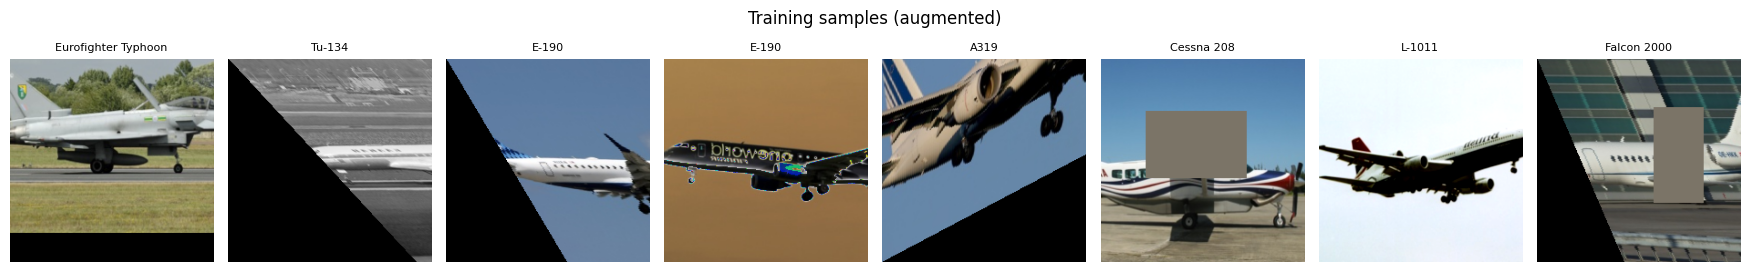

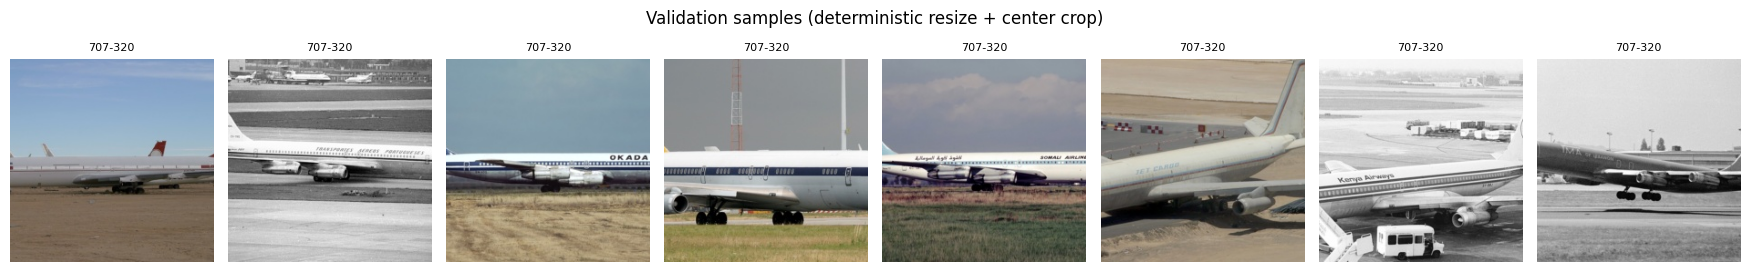

In [7]:
def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)


def show_batch(loader, title, n=8):
    xb, yb = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
    for ax, img, y in zip(axes, xb[:n], yb[:n]):
        ax.imshow(denorm(img).permute(1, 2, 0).numpy())
        ax.set_title(classes[y], fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(train_loader, "Training samples (augmented)")
show_batch(val_loader, "Validation samples (deterministic resize + center crop)")

## 2. Part 1 — Designing our network from scratch

### Architecture

To tackle the task, we build a compact **residual CNN** entirely as a composition of `torch.nn` layers:

- **Stem**: two 3x3 convolutions (the first with stride 2) + BatchNorm + ReLU, followed by a 3x3 max-pool with stride 2. A stack of small convolutions is a gentler feature extractor that works better when training from scratch on small datasets.
- **Body**: four stages of residual basic blocks with layout **2-2-2-2** and widths **64→128→256→512**; the first block of stages 2-4 downsamples with stride 2. Each block is `conv3x3-BN-ReLU-conv3x3-BN` plus an identity (or 1x1 projection) shortcut, then a final ReLU (He et al., *Deep Residual Learning*, CVPR 2016).
- **Head**: global average pooling, followed by dropout 0.3, followed by a final linear layer to 100 classes.

The two structural design choices we will ablate are **residual connections** and **BatchNorm** (Ioffe & Szegedy, ICML 2015).

### Training recipe

| Component | Value | Why |
|---|---|---|
| Optimizer | AdamW, lr 3e-3, wd 0.05 | Decoupled weight decay regularizes well at from-scratch scale (Loshchilov & Hutter, ICLR 2019) |
| Schedule | 5-epoch linear warmup → cosine decay | Warmup avoids early instability; cosine reliably beats constant/step LR (He et al., *Bag of Tricks*, CVPR 2019) |
| Loss | Cross-entropy, label smoothing 0.1 | Regularizes over-confident logits (Müller et al., NeurIPS 2019) |
| Augmentation | RandomResizedCrop + flip + TrivialAugmentWide + RandomErasing | Main defense against overfitting 3.3k images |
| Regularization | Dropout 0.3 before the classifier | Cheap extra regularization on the head |
| Stability | Gradient-norm clipping at 1.0, AMP mixed precision | Clipping keeps all runs (incl. the no-BN ablation) on the same recipe; AMP ≈ 2× speedup |
| Budget | 80 epochs, batch 128 | From-scratch fine-grained training needs long schedules |

All components involved in the study are exposed as constructor flags, so that each ablation is a one-flag change of the same code.

In [8]:
class ResidualBlock(nn.Module):
    """Basic 2-conv block with optional BatchNorm and optional residual shortcut."""

    def __init__(self, cin, cout, stride=1, use_bn=True, use_residual=True):
        super().__init__()
        norm = (lambda c: nn.BatchNorm2d(c)) if use_bn else (lambda c: nn.Identity())
        bias = not use_bn
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=bias)
        self.bn1 = norm(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, stride=1, padding=1, bias=bias)
        self.bn2 = norm(cout)
        self.use_residual = use_residual
        if use_residual and (stride != 1 or cin != cout):
            self.shortcut = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=bias), norm(cout)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_residual:
            out = out + self.shortcut(x)
        return F.relu(out)


class AircraftNet(nn.Module):
    def __init__(self, num_classes=100, dropout=0.3, use_bn=True, use_residual=True,
                 widths=(64, 128, 256, 512), blocks=(2, 2, 2, 2)):
        super().__init__()
        norm = (lambda c: nn.BatchNorm2d(c)) if use_bn else (lambda c: nn.Identity())
        bias = not use_bn
        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0], 3, stride=2, padding=1, bias=bias), norm(widths[0]), nn.ReLU(inplace=True),
            nn.Conv2d(widths[0], widths[0], 3, stride=1, padding=1, bias=bias), norm(widths[0]), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        stages, cin = [], widths[0]
        for stage_idx, (w, n) in enumerate(zip(widths, blocks)):
            for b in range(n):
                stride = 2 if (b == 0 and stage_idx > 0) else 1
                stages.append(ResidualBlock(cin, w, stride, use_bn=use_bn, use_residual=use_residual))
                cin = w
        self.body = nn.Sequential(*stages)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, num_classes)
        )

    def forward(self, x):
        return self.head(self.body(self.stem(x)))


_m = AircraftNet(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in _m.parameters())
print(f"AircraftNet parameters: {n_params/1e6:.2f} M")
with torch.no_grad():
    print("output shape:", _m(torch.randn(2, 3, CFG.img_size, CFG.img_size)).shape)
del _m

AircraftNet parameters: 11.26 M
output shape: torch.Size([2, 100])


### Training engine

We build a single generic engine shared by *every* run in this notebook (best model, all ablations, Part 2A and 2B), which guarantees that runs differ *only* in the component under study. Each run writes a `*_history.json` after every epoch and checkpoints `*_best.pt` at the best validation accuracy; with `SKIP_TRAINING = True`, `run_experiment` reloads both instead of retraining.

In [9]:
RESULTS = {}   # name -> (model with best weights, history dict)
TEST_ACC = {}  # name -> final test accuracy


def _make_scaler():
    try:
        return torch.amp.GradScaler(device.type, enabled=device.type == "cuda")
    except (TypeError, AttributeError):
        return torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


def train_one_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    criterion = criterion or nn.CrossEntropyLoss()
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out = model(x)
            loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n


def fit(name, model, optimizer, scheduler, epochs, train_ld, val_ld, criterion, history=None):
    scaler = _make_scaler()
    history = history if history is not None else {k: [] for k in
                ["train_loss", "train_acc", "val_loss", "val_acc", "lr"]}
    best_acc = max(history["val_acc"], default=-1.0)  # -1 so the first epoch always checkpoints
    ckpt = OUTPUT_DIR / f"{name}_best.pt"
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_ld, optimizer, scaler, criterion)
        vl, va = evaluate(model, val_ld, criterion)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        if scheduler is not None:
            scheduler.step()
        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"], [tl, ta, vl, va]):
            history[k].append(v)
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), ckpt)
        (OUTPUT_DIR / f"{name}_history.json").write_text(json.dumps(history))
        print(f"[{name}] epoch {epoch:3d}/{epochs} | "
              f"train {tl:.3f}/{ta:.3f} | val {vl:.3f}/{va:.3f} | "
              f"best {best_acc:.3f} | {time.time() - t0:.0f}s")
    return history


def build_scheduler(optimizer, epochs, warmup):
    warmup = min(warmup, max(epochs - 1, 1))  # guard tiny-budget edge cases
    warm = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.02, total_iters=warmup)
    cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs - warmup, 1))
    return torch.optim.lr_scheduler.SequentialLR(optimizer, [warm, cos], milestones=[warmup])


def run_experiment(name, model_fn, epochs, use_aug=True, use_scheduler=True,
                   lr=None, label_smoothing=None):
    """One complete training run."""
    lr = CFG.lr if lr is None else lr
    label_smoothing = CFG.label_smoothing if label_smoothing is None else label_smoothing
    hist_file = OUTPUT_DIR / f"{name}_history.json"
    ckpt_file = OUTPUT_DIR / f"{name}_best.pt"

    if SKIP_TRAINING and hist_file.exists() and ckpt_file.exists():
        history = json.loads(hist_file.read_text())
        model = model_fn().to(device)
        model.load_state_dict(torch.load(ckpt_file, map_location=device))
        print(f"[{name}] loaded saved run (best val acc {max(history['val_acc']):.3f})")
        RESULTS[name] = (model, history)
        return model, history

    seed_everything(CFG.seed)
    model = model_fn().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=CFG.weight_decay)
    scheduler = build_scheduler(optimizer, epochs, CFG.warmup_epochs) if use_scheduler else None
    train_ld = train_loader if use_aug else train_loader_noaug

    history = fit(name, model, optimizer, scheduler, epochs, train_ld, val_loader, criterion)
    model.load_state_dict(torch.load(ckpt_file, map_location=device))  # restore best weights
    RESULTS[name] = (model, history)
    return model, history

### 2.1 Best model — full 80-epoch run

In [10]:
model_best, hist_best = run_experiment(
    "part1_best",
    lambda: AircraftNet(num_classes=NUM_CLASSES, dropout=CFG.dropout),
    epochs=CFG.epochs_best,
)

[part1_best] epoch   1/80 | train 4.698/0.017 | val 4.650/0.010 | best 0.010 | 34s
[part1_best] epoch   2/80 | train 4.648/0.018 | val 4.973/0.024 | best 0.024 | 21s
[part1_best] epoch   3/80 | train 4.601/0.026 | val 5.346/0.010 | best 0.024 | 20s
[part1_best] epoch   4/80 | train 4.577/0.027 | val 6.005/0.014 | best 0.024 | 20s
[part1_best] epoch   5/80 | train 4.501/0.028 | val 4.670/0.030 | best 0.030 | 20s
[part1_best] epoch   6/80 | train 4.485/0.030 | val 8.437/0.014 | best 0.030 | 19s
[part1_best] epoch   7/80 | train 4.431/0.031 | val 4.327/0.038 | best 0.038 | 21s
[part1_best] epoch   8/80 | train 4.353/0.040 | val 4.442/0.037 | best 0.038 | 20s
[part1_best] epoch   9/80 | train 4.286/0.045 | val 4.176/0.041 | best 0.041 | 20s
[part1_best] epoch  10/80 | train 4.213/0.047 | val 5.713/0.019 | best 0.041 | 19s
[part1_best] epoch  11/80 | train 4.175/0.050 | val 4.582/0.047 | best 0.047 | 21s
[part1_best] epoch  12/80 | train 4.114/0.062 | val 4.181/0.060 | best 0.060 | 19s
[par

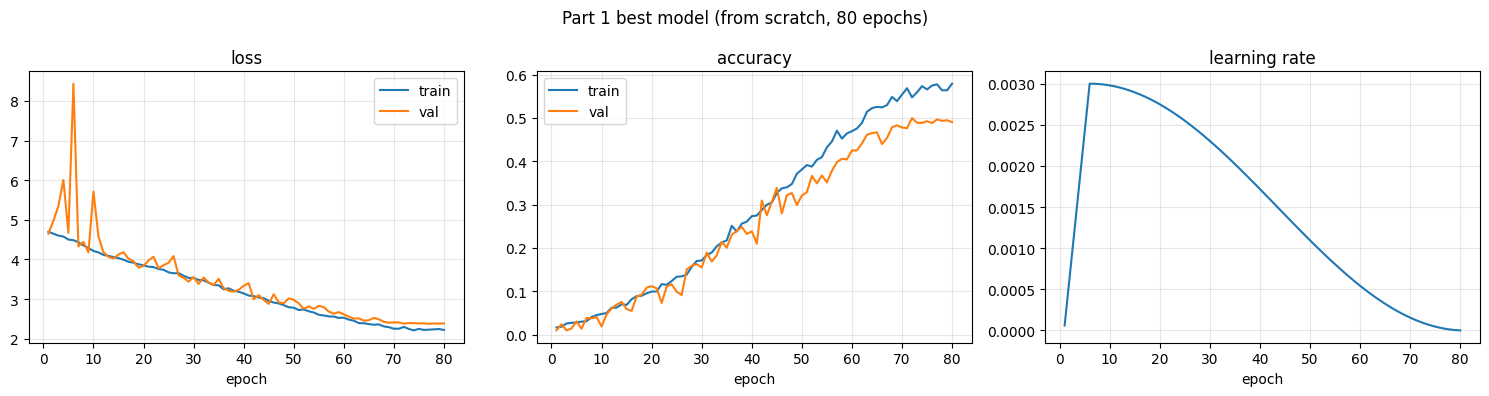

Part 1 best model — TEST accuracy: 0.5044


In [11]:
def plot_run(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="train")
    axes[0].plot(ep, history["val_loss"], label="val")
    axes[0].set_title("loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history["train_acc"], label="train")
    axes[1].plot(ep, history["val_acc"], label="val")
    axes[1].set_title("accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(ep, history["lr"])
    axes[2].set_title("learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


plot_run(hist_best, "Part 1 best model (from scratch, 80 epochs)")

_, test_acc_best = evaluate(model_best, test_loader)
TEST_ACC["part1_best"] = test_acc_best
print(f"Part 1 best model — TEST accuracy: {test_acc_best:.4f}")

After training from scratch for 80 epochs, our model breaks the 50% accuracy wall (50.44%) when evaluated on the test set, coherently with the performance obtained on the validation, and showing *no sign of overfitting*, as we can also notice from the plotted training curves.

### 2.2 Ablation study

Starting from the best configuration, we remove **one component at a time** and retrain, keeping everything else — architecture, data, seed, optimizer, batch size — identical. Every ablation is trained with an **equal budget of 80 epochs**, as the best model we obtained in 2.1, and then compared to it in terms of accuracy.

| Run | Component removed | What we expect it to show |
|---|---|---|
| `abl_no_aug` | Data augmentation (deterministic resize + crop only) | Severe overfitting: train accuracy reaches ~100%, validation stalls |
| `abl_no_residual` | Residual shortcuts (same depth, plain CNN) | Harder optimization of an 18-layer plain network (He et al., 2016) |
| `abl_no_batchnorm` | BatchNorm (replaced by identity, conv bias on) | Instability / much slower convergence at the same lr (Ioffe & Szegedy, 2015) |
| `abl_const_lr` | LR schedule (constant 3e-3, no warmup/cosine) | Missing final-phase convergence of cosine decay (He et al., 2019) |
| `abl_no_labelsmooth` | Label smoothing (ε = 0) | Smaller but measurable drop; over-confident logits |

In [12]:
ablation_specs = {
    "abl_no_aug":         dict(use_aug=False),
    "abl_no_residual":    dict(model_kwargs=dict(use_residual=False)),
    "abl_no_batchnorm":   dict(model_kwargs=dict(use_bn=False)),
    "abl_const_lr":       dict(use_scheduler=False),
    "abl_no_labelsmooth": dict(label_smoothing=0.0),
}

for name, spec in ablation_specs.items():
    spec = dict(spec)
    mkw = spec.pop("model_kwargs", {})
    run_experiment(
        name,
        lambda mkw=mkw: AircraftNet(num_classes=NUM_CLASSES, dropout=CFG.dropout, **mkw),
        epochs=CFG.epochs_ablation,
        **spec,
    )

[abl_no_aug] epoch   1/80 | train 4.633/0.016 | val 4.690/0.015 | best 0.015 | 15s
[abl_no_aug] epoch   2/80 | train 4.477/0.039 | val 12.499/0.013 | best 0.015 | 15s
[abl_no_aug] epoch   3/80 | train 4.281/0.051 | val 5.574/0.021 | best 0.021 | 14s
[abl_no_aug] epoch   4/80 | train 4.029/0.081 | val 4.947/0.054 | best 0.054 | 15s
[abl_no_aug] epoch   5/80 | train 3.851/0.104 | val 4.620/0.061 | best 0.061 | 15s
[abl_no_aug] epoch   6/80 | train 3.733/0.124 | val 4.739/0.087 | best 0.087 | 15s
[abl_no_aug] epoch   7/80 | train 3.522/0.150 | val 4.535/0.067 | best 0.087 | 15s
[abl_no_aug] epoch   8/80 | train 3.267/0.222 | val 3.845/0.136 | best 0.136 | 14s
[abl_no_aug] epoch   9/80 | train 3.115/0.254 | val 4.375/0.108 | best 0.136 | 14s
[abl_no_aug] epoch  10/80 | train 2.970/0.291 | val 3.566/0.171 | best 0.171 | 15s
[abl_no_aug] epoch  11/80 | train 2.807/0.347 | val 3.637/0.183 | best 0.183 | 15s
[abl_no_aug] epoch  12/80 | train 2.646/0.401 | val 3.337/0.248 | best 0.248 | 15s
[ab

We evaluate the test accuracy for every ablation run and compare it with the best model accuracy.

In [24]:
for name, (model, _) in RESULTS.items():
    if name not in TEST_ACC:
        _, TEST_ACC[name] = evaluate(model, test_loader)

pretty = {
    "part1_best": "Best model",
    "abl_no_aug": "— data augmentation",
    "abl_no_residual": "— residual connections",
    "abl_no_batchnorm": "— BatchNorm",
    "abl_const_lr": "— LR schedule (constant lr)",
    "abl_no_labelsmooth": "— label smoothing",
}
ref = TEST_ACC["part1_best"]
rows = []
for name in pretty:
    if name not in TEST_ACC:
        continue
    _, hist = RESULTS[name]
    rows.append({
        "run": pretty[name],
        "epochs": len(hist["val_acc"]),
        "best val acc": max(hist["val_acc"]),
        "test acc": TEST_ACC[name],
        "Δ test vs best model": TEST_ACC[name] - ref if name.startswith("abl") else 0,
    })
df_abl = pd.DataFrame(rows).set_index("run").round(4)
df_abl

,epochs,best val acc,test acc,Δ test vs best model
run,,,,
Best model,80,0.4995,0.5044,0.0000
— data augmentation,80,0.4710,0.4827,-0.0216
— residual connections,80,0.3168,0.3129,-0.1914
— BatchNorm,80,0.1905,0.1908,-0.3135
— LR schedule (constant lr),80,0.4629,0.4644,-0.0399
— label smoothing,80,0.4776,0.4803,-0.0240


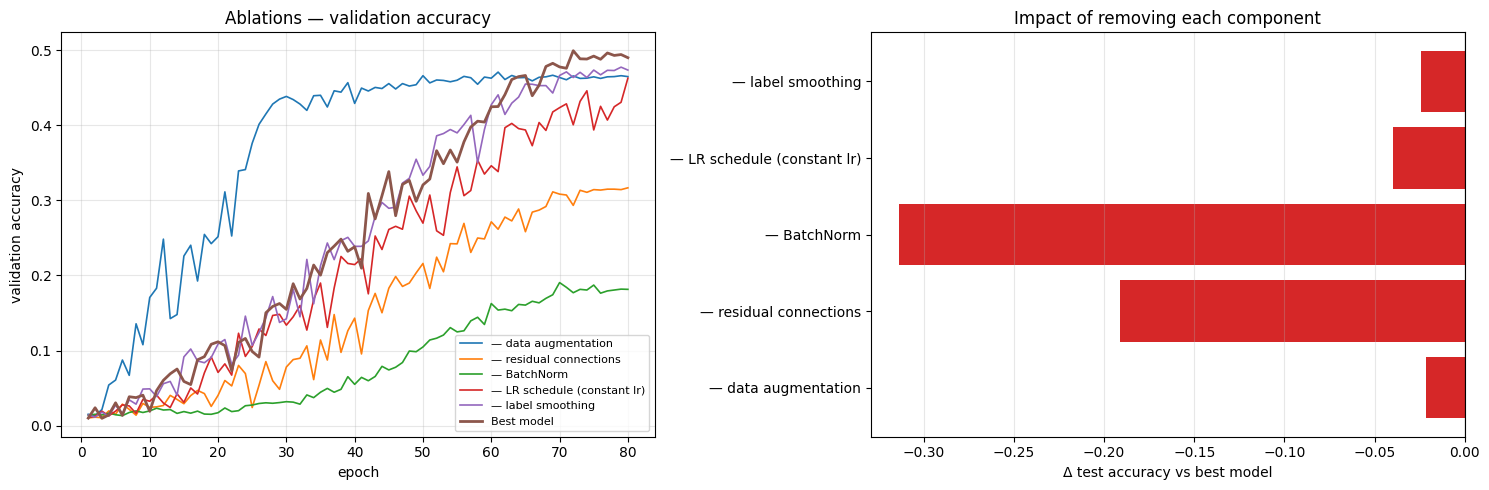

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


ablation_specs.update({"part1_best": {}})

# Overlaid validation-accuracy curves
for name in ablation_specs:
    _, hist = RESULTS[name]
    axes[0].plot(range(1, len(hist["val_acc"]) + 1), hist["val_acc"],
                 label=pretty[name], linewidth=2 if name == "part1_best" else 1.2)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Ablations — validation accuracy")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart of test-accuracy deltas
abl_names = [n for n in ablation_specs if n != "part1_best"]
deltas = [TEST_ACC[n] - ref for n in abl_names]
colors = ["tab:red" if d < 0 else "tab:green" for d in deltas]
axes[1].barh([pretty[n] for n in abl_names], deltas, color=colors)
axes[1].axvline(0, color="k", linewidth=0.8)
axes[1].set_xlabel("Δ test accuracy vs best model")
axes[1].set_title("Impact of removing each component")
axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

In the plots we are able to see the impact each component has on the network performance. These results are better explained in the final discussion about Part 1.

### 2.3 Qualitative analysis of the best model

We inspect the (row-normalized) confusion matrix, the most confused class pairs, the best/worst classes, and a grid of sample predictions. On FGVC-Aircraft, errors typically concentrate *within* aircraft families — e.g. 737-600/-700/-800/-900 or A319/A320/A321 — which differ only in fuselage length, window count, and engine details, as demonstrated by the confused-pairs list below.

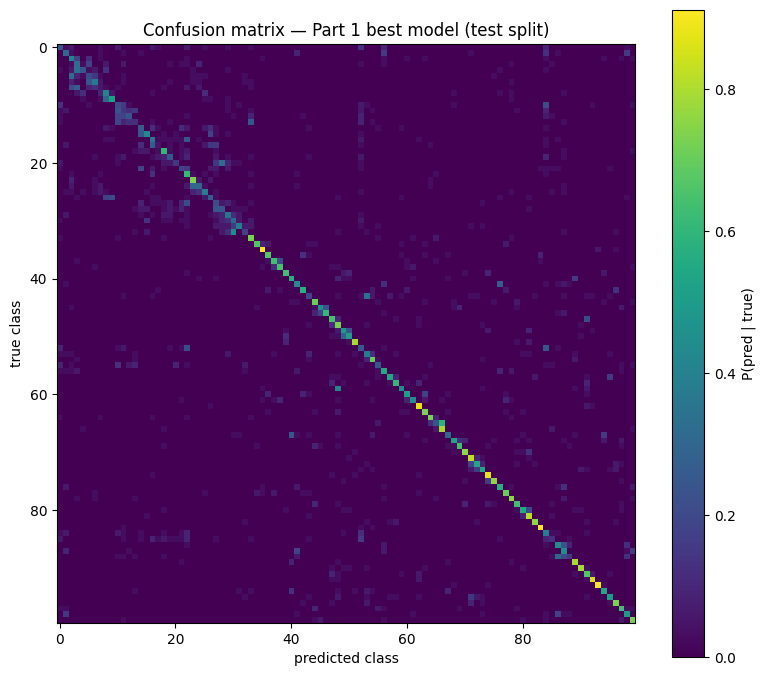

Most confused pairs (true -> predicted, count):
               E-190 -> E-195              : 20
            A340-600 -> A340-300           : 15
               DHC-6 -> Cessna 208         : 14
                C-47 -> DC-3               : 11
             737-400 -> 737-300            : 11
             777-300 -> A330-300           : 11
             737-500 -> 737-200            : 11
          Cessna 560 -> Cessna 525         : 10
             737-900 -> 737-800            : 10
               MD-90 -> MD-80              : 10
                A319 -> A318               : 10
          Boeing 717 -> Fokker 100         : 9

Hardest classes: [('767-300', np.float64(0.06)), ('737-700', np.float64(0.06)), ('747-400', np.float64(0.12)), ('MD-11', np.float64(0.12)), ('777-300', np.float64(0.15))]
Easiest classes: [('DR-400', np.float64(0.88)), ('Falcon 2000', np.float64(0.88)), ('Saab 2000', np.float64(0.91)), ('ATR-72', np.float64(0.91)), ('Il-76', np.float64(0.91))]


In [26]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds, targets = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out = model(x)
        preds.append(out.argmax(1).cpu())
        targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


preds, targets = predict_all(model_best, test_loader)
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
np.add.at(cm, (targets, preds), 1)
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 7))
plt.imshow(cm_norm, cmap="viridis")
plt.colorbar(label="P(pred | true)")
plt.title("Confusion matrix — Part 1 best model (test split)")
plt.xlabel("predicted class"); plt.ylabel("true class")
plt.tight_layout(); plt.show()

# Most confused pairs
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:12], off.shape))[0]
print("Most confused pairs (true -> predicted, count):")
for i, j in pairs:
    print(f"  {classes[i]:>18s} -> {classes[j]:<18s} : {off[i, j]}")

# Best / worst classes
per_class = np.diag(cm_norm)
order = np.argsort(per_class)
print("\nHardest classes:", [(classes[i], round(per_class[i], 2)) for i in order[:5]])
print("Easiest classes:", [(classes[i], round(per_class[i], 2)) for i in order[-5:]])

We sample some correct and incorrect test predictions.

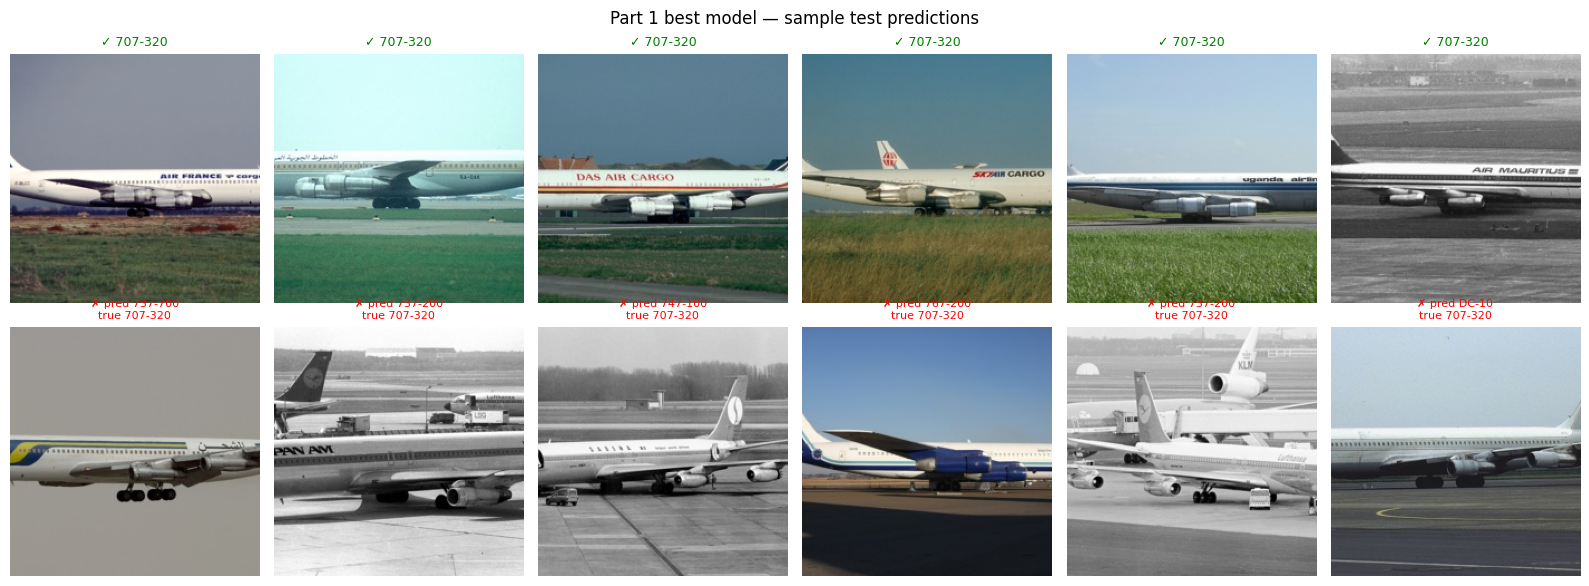

In [27]:
xb, yb = next(iter(test_loader))
with torch.no_grad(), torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
    pb = model_best(xb.to(device)).argmax(1).cpu()

correct_idx = [i for i in range(len(yb)) if pb[i] == yb[i]][:6]
wrong_idx = [i for i in range(len(yb)) if pb[i] != yb[i]][:6]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, i in zip(axes[0], correct_idx):
    ax.imshow(denorm(xb[i]).permute(1, 2, 0).numpy())
    ax.set_title(f"✓ {classes[pb[i]]}", color="green", fontsize=9); ax.axis("off")
for ax, i in zip(axes[1], wrong_idx):
    ax.imshow(denorm(xb[i]).permute(1, 2, 0).numpy())
    ax.set_title(f"✗ pred {classes[pb[i]]}\ntrue {classes[yb[i]]}", color="red", fontsize=8); ax.axis("off")
fig.suptitle("Part 1 best model — sample test predictions")
plt.tight_layout(); plt.show()

### 2.4 Part 1 — Discussion

The best model reaches **~50% validation / 50.44% test accuracy**, meeting the
~50% target we had. Every ablation was then retrained with the *identical* 80-epoch budget.

The ablation study taught us that:

* **BatchNorm is the single most critical component** (19.1% test, **Δ = -31.4
points**). Without normalization the network still trains (gradient clipping and
warmup keep it stable) but optimization is dramatically slower and shallower: at the
same learning rate the un-normalized network cannot exploit the loss landscape the
way the baseline does (Ioffe & Szegedy, 2015).

* **Residual connections are second** (31.3% test, **Δ = -19.1 points**). The
plain 18-layer network of identical depth and width loses ~19 points, the
degradation phenomenon that motivated residual learning (He et al., 2016). Both
structural ablations lead to *training* accuracy far below the baseline's, so these
are optimization failures rather than overfitting.

* **The cosine schedule contributes a solid and cheap gain** (46.4% test,
**Δ = -4.0 points**). The constant-lr run tracks the baseline for much of training
but misses the final refinement phase that annealing the learning rate unlocks.

* **Data augmentation improves the ceiling but not the speed** (48.3% test, **Δ = -2.2
points**). The no-augmentation run converges much faster: its training accuracy
saturates early while the augmented baseline is still climbing, but it memorizes
the 3.3k training images and plateaus, ending 2.2 points below the baseline with a
far larger train/validation gap (visible in the overlaid curves above). The correct
reading is therefore that augmentation trades convergence speed for a higher accuracy ceiling.

* **Label smoothing contributes a small real gain** (48.0% test, **Δ = -2.4
points**), consistent with its role as a mild regularizer of over-confident logits
(Müller et al., 2019). Its effect is of the same order as augmentation's at this
operating point: though, these "cheap" regularizers together have a not negligible impact.

The results rest on two levels of design choices: *optimization enablers* (BatchNorm, residual connections which are jointly worth ~50 points) and *refinement/regularization
components* (cosine schedule, label smoothing, augmentation which are worth ~2-4 points
each, which together are the difference between ~42% and ~50%).

## 3. Part 2 — Fine-tuning a pretrained ResNet-18

We now use the **off-the-shelf** `torchvision.models.resnet18` with `ResNet18_Weights.IMAGENET1K_V1`, replacing only the final fully-connected layer with a fresh 100-way classifier. The data pipeline is unchanged, in particular the ImageNet normalization chosen in Section 1, which is exactly what ResNet weights expect.

### 3.1 Part 2A — Using the same hyperparameters as Part 1

We first fine-tune with the *identical* recipe used for the best Part 1 model: AdamW lr 3e-3 / wd 0.05, 5-epoch warmup + cosine, label smoothing 0.1, the same augmentation, and the same 80-epoch budget.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


[part2a_resnet18_samehp] epoch   1/80 | train 4.683/0.019 | val 4.459/0.052 | best 0.052 | 21s
[part2a_resnet18_samehp] epoch   2/80 | train 3.952/0.138 | val 3.419/0.216 | best 0.216 | 21s
[part2a_resnet18_samehp] epoch   3/80 | train 3.287/0.247 | val 3.690/0.191 | best 0.216 | 19s
[part2a_resnet18_samehp] epoch   4/80 | train 3.160/0.276 | val 3.791/0.213 | best 0.216 | 23s
[part2a_resnet18_samehp] epoch   5/80 | train 3.169/0.270 | val 3.843/0.159 | best 0.216 | 28s
[part2a_resnet18_samehp] epoch   6/80 | train 3.185/0.266 | val 3.596/0.228 | best 0.228 | 21s
[part2a_resnet18_samehp] epoch   7/80 | train 3.077/0.301 | val 3.393/0.263 | best 0.263 | 22s
[part2a_resnet18_samehp] epoch   8/80 | train 2.961/0.331 | val 3.747/0.199 | best 0.263 | 24s
[part2a_resnet18_samehp] epoch   9/80 | train 2.761/0.390 | val 3.501/0.252 | best 0.263 | 20s
[part2a_resnet18_samehp] epoch  10/80 | train 2.724/0.392 | val 2.952/0.350 | best 0.350 | 22s
[part2a_resnet18_samehp] epoch  11/80 | train 2.63

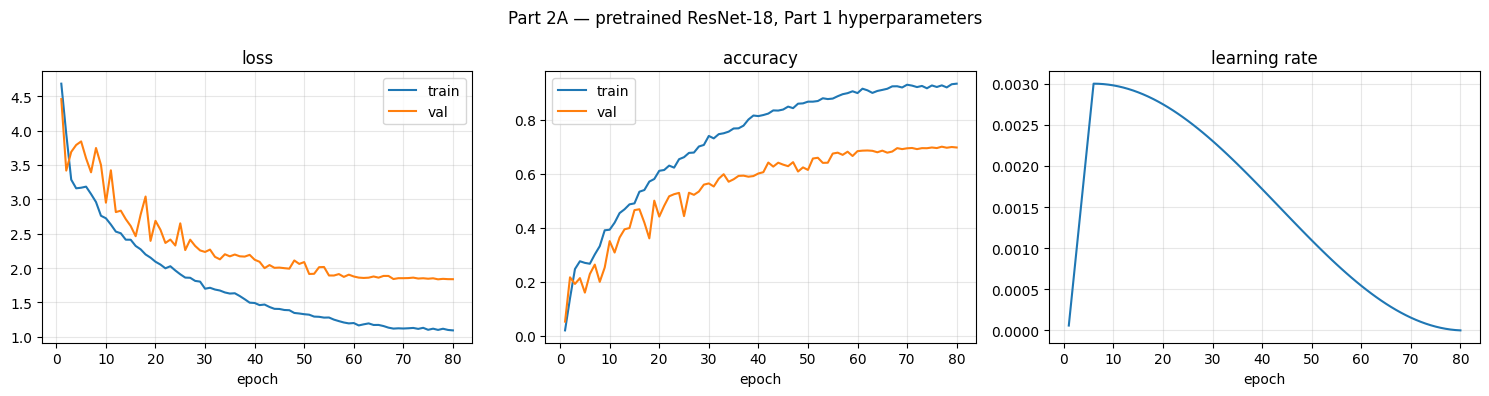

Part 2A — TEST accuracy: 0.7057


In [28]:
from torchvision.models import ResNet18_Weights, resnet18


def make_resnet18_pretrained():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)  # new 100-way head
    return m


model_2a, hist_2a = run_experiment(
    "part2a_resnet18_samehp", make_resnet18_pretrained, epochs=CFG.epochs_best
)

plot_run(hist_2a, "Part 2A — pretrained ResNet-18, Part 1 hyperparameters")
_, TEST_ACC["part2a_resnet18_samehp"] = evaluate(model_2a, test_loader)
print(f"Part 2A — TEST accuracy: {TEST_ACC['part2a_resnet18_samehp']:.4f}")

As we can see, after fine-tuning ResNet-18 using the same hyperparameters as in Part 1, we already reach a ~70% test accuracy.

### 3.2 Part 2B — Adapting the fine-tuning recipe

**Diagnosis from 2A.** The same-hyperparameter run reaches **70.0% best validation /
70.6% test** — ImageNet pretraining alone is worth ~20 points over the from-scratch
model, even with a recipe tuned for random initialization. The training log, however,
suggests that recipe is fighting the pretrained weights: in fact, at epoch 2, while warmup still holds the learning rate near 2e-4, validation accuracy is already **21.6%**. Then, as warmup ramps the lr toward its 3e-3 peak, validation drops and oscillates (21.6% → 19.1% → 21.3% → 15.9% over epochs 3-5) and only durably passes its epoch-2 level at epoch 10. Large updates, which are driven initially by gradients from the randomly initialized head, appear to be damaging the ImageNet features.

Therefore, our first attempt is to **lower the learning rate for the pretrained backbone.** In fact, the standard prescription for this failure mode is to train the backbone more gently than the fresh head. So, we kept 2A's schedule shape and budget (5-epoch warmup + cosine, 80 epochs, identical augmentation and regularization) and changed only the learning rates: backbone peak lowered from 3e-3 to **1e-3**, head kept at 3e-3 (this is justified because the head is the only randomly initialized part).

In [37]:
name_2b = "part2b_resnet18_tuned"
EPOCHS_2B = 80                       # identical budget and schedule shape to 2A
BACKBONE_LR, HEAD_LR = 1e-3, 3e-3    # the single change vs 2A
hist_file = OUTPUT_DIR / f"{name_2b}_history.json"
ckpt_file = OUTPUT_DIR / f"{name_2b}_best.pt"

if SKIP_TRAINING and hist_file.exists() and ckpt_file.exists():
    hist_2b = json.loads(hist_file.read_text())
    model_2b = make_resnet18_pretrained().to(device)
    model_2b.load_state_dict(torch.load(ckpt_file, map_location=device))
    print(f"[{name_2b}] loaded saved run (best val acc {max(hist_2b['val_acc']):.3f})")
else:
    seed_everything(CFG.seed)
    model_2b = make_resnet18_pretrained().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
    backbone = [p for n, p in model_2b.named_parameters() if not n.startswith("fc.")]
    head = list(model_2b.fc.parameters())

    opt = torch.optim.AdamW(
        [{"params": backbone, "lr": BACKBONE_LR}, {"params": head, "lr": HEAD_LR}],
        weight_decay=CFG.weight_decay,
    )
    # same warmup+cosine shape as 2A: the warmup ramp replaces the linear probe
    # (head starts at ~6e-5, so random-head gradients cannot damage the backbone)
    sched = build_scheduler(opt, EPOCHS_2B, CFG.warmup_epochs)
    hist_2b = fit(name_2b, model_2b, opt, sched, EPOCHS_2B,
                  train_loader, val_loader, criterion)
    model_2b.load_state_dict(torch.load(ckpt_file, map_location=device))

RESULTS[name_2b] = (model_2b, hist_2b)
_, TEST_ACC[name_2b] = evaluate(model_2b, test_loader)
print(f"Part 2B — TEST accuracy: {TEST_ACC[name_2b]:.4f}")

[part2b_resnet18_tuned] epoch   1/80 | train 4.734/0.014 | val 4.616/0.023 | best 0.023 | 21s
[part2b_resnet18_tuned] epoch   2/80 | train 4.285/0.091 | val 3.713/0.153 | best 0.153 | 20s
[part2b_resnet18_tuned] epoch   3/80 | train 3.465/0.237 | val 3.140/0.261 | best 0.261 | 22s
[part2b_resnet18_tuned] epoch   4/80 | train 2.933/0.341 | val 3.450/0.197 | best 0.261 | 20s
[part2b_resnet18_tuned] epoch   5/80 | train 2.668/0.422 | val 3.065/0.359 | best 0.359 | 20s
[part2b_resnet18_tuned] epoch   6/80 | train 2.633/0.423 | val 3.578/0.285 | best 0.359 | 22s
[part2b_resnet18_tuned] epoch   7/80 | train 2.500/0.474 | val 3.447/0.301 | best 0.359 | 21s
[part2b_resnet18_tuned] epoch   8/80 | train 2.401/0.508 | val 2.849/0.373 | best 0.373 | 22s
[part2b_resnet18_tuned] epoch   9/80 | train 2.302/0.537 | val 2.741/0.405 | best 0.405 | 22s
[part2b_resnet18_tuned] epoch  10/80 | train 2.228/0.559 | val 2.855/0.414 | best 0.414 | 21s
[part2b_resnet18_tuned] epoch  11/80 | train 2.184/0.584 | v

We obtained a **69.5% test accuracy**, which is below 2A. The change worked as intended locally: the early-epoch collapse was attenuated, yet the final score dropped. We can notice that at the lower learning rate the network memorizes the training set much earlier (training accuracy crosses 90% tens of epochs sooner than in 2A), instead validation plateaus with a *larger* generalization gap.
We can therefore suppose that 2A's aggressive learning rate plays a second beneficial role: large noisy updates delay memorization of the 3.3k images, acting as an **implicit regularizer**.

So, the 2A recipe is (most likely) already at its learning-rate optimum, being able to recover from the early feature damage. Thus, we can conclude that *optimization is not the binding constraint of this setup*.

### 3.3 Part 2B — Final fine-tuning recipe

If optimization is saturated, we speculate that the constraint must lie in the information reaching the network. This task is *fine-grained*: i.e. the 100 classes are variants of the same airframes, distinguished by window count, fuselage proportions, door placement, etc. This content can be partially destroyed by downsampling to 224x224. Since ImageNet-style resolution is calibrated for basic-level categories, not subordinate ones; it is standard practice in the fine-grained literature to use higher input resolutions.

The final recipe therefore keeps the one used in 2A: same optimizer, learning rate
3e-3, weight decay, warmup + cosine, label smoothing, augmentation pipeline, batch
size, and 80-epoch budget; but changes exactly one hyperparameter: **input size goes from 224 to 288** (images cached at short side 320, evaluation with resize 320 + center crop at 288).

In [41]:
from dataclasses import replace

CFG_HI = replace(CFG, cache_dir="./data/fgvc_cache_320", resize_short=320)
IMG_HI = 288  # new input resolution

cached_hi = {split: build_cache(raw[split], split, CFG_HI) for split in ["train", "val", "test"]}

train_tf_hi = transforms.Compose([
    transforms.RandomResizedCrop(IMG_HI, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])
eval_tf_hi = transforms.Compose([
    transforms.Resize(CFG_HI.resize_short),
    transforms.CenterCrop(IMG_HI),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_loader_hi = make_loader(cached_hi["train"], train_tf_hi, shuffle=True)
val_loader_hi   = make_loader(cached_hi["val"],   eval_tf_hi, shuffle=False)
test_loader_hi  = make_loader(cached_hi["test"],  eval_tf_hi, shuffle=False)

caching train:   0%|          | 0/3334 [00:00<?, ?it/s]

caching val:   0%|          | 0/3333 [00:00<?, ?it/s]

caching test:   0%|          | 0/3333 [00:00<?, ?it/s]

In [42]:
name_2b = "part2b_resnet18_hires"
EPOCHS_2B = 80
hist_file = OUTPUT_DIR / f"{name_2b}_history.json"
ckpt_file = OUTPUT_DIR / f"{name_2b}_best.pt"

if SKIP_TRAINING and hist_file.exists() and ckpt_file.exists():
    hist_2b = json.loads(hist_file.read_text())
    model_2b = make_resnet18_pretrained().to(device)
    model_2b.load_state_dict(torch.load(ckpt_file, map_location=device))
    print(f"[{name_2b}] loaded saved run (best val acc {max(hist_2b['val_acc']):.3f})")
else:
    seed_everything(CFG.seed)
    model_2b = make_resnet18_pretrained().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
    optimizer = torch.optim.AdamW(model_2b.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = build_scheduler(optimizer, EPOCHS_2B, CFG.warmup_epochs)
    hist_2b = fit(name_2b, model_2b, optimizer, scheduler, EPOCHS_2B,
                  train_loader_hi, val_loader_hi, criterion)
    model_2b.load_state_dict(torch.load(ckpt_file, map_location=device))

RESULTS[name_2b] = (model_2b, hist_2b)
_, TEST_ACC[name_2b] = evaluate(model_2b, test_loader_hi)
print(f"Part 2B — TEST accuracy: {TEST_ACC[name_2b]:.4f}")

[part2b_resnet18_hires] epoch   1/80 | train 4.638/0.017 | val 4.427/0.063 | best 0.063 | 46s
[part2b_resnet18_hires] epoch   2/80 | train 3.905/0.149 | val 3.348/0.210 | best 0.210 | 31s
[part2b_resnet18_hires] epoch   3/80 | train 3.219/0.267 | val 3.296/0.238 | best 0.238 | 31s
[part2b_resnet18_hires] epoch   4/80 | train 2.974/0.318 | val 3.865/0.171 | best 0.238 | 31s
[part2b_resnet18_hires] epoch   5/80 | train 2.975/0.318 | val 3.339/0.254 | best 0.254 | 31s
[part2b_resnet18_hires] epoch   6/80 | train 2.946/0.326 | val 3.675/0.260 | best 0.260 | 31s
[part2b_resnet18_hires] epoch   7/80 | train 2.865/0.362 | val 3.174/0.270 | best 0.270 | 32s
[part2b_resnet18_hires] epoch   8/80 | train 2.768/0.388 | val 3.044/0.342 | best 0.342 | 31s
[part2b_resnet18_hires] epoch   9/80 | train 2.654/0.413 | val 3.154/0.361 | best 0.361 | 31s
[part2b_resnet18_hires] epoch  10/80 | train 2.578/0.442 | val 3.454/0.323 | best 0.361 | 31s
[part2b_resnet18_hires] epoch  11/80 | train 2.520/0.458 | v

The change in the input resolution resulted in **+4.8 points over 2A** (**75.4% test accuracy**), exceeding the ~70% target. The early epochs behave like 2A's (including the same benign warmup oscillation, since the lr treatment is identical), but from
mid-training onward the validation curve separates decisively upward (e.g. 69.2% at
epoch 46, where 2A sat at ~64%), and it is still improving when the cosine anneals
(from 71.9% to 74.1% over the final 20 epochs). The generalization gap also shrinks
relative to 2A (94.3/74.1 vs 93.4/70.0) even though the regularization is unchanged: it's reasonable to think that with more discriminative detail available in the input, the network can better separate classes.

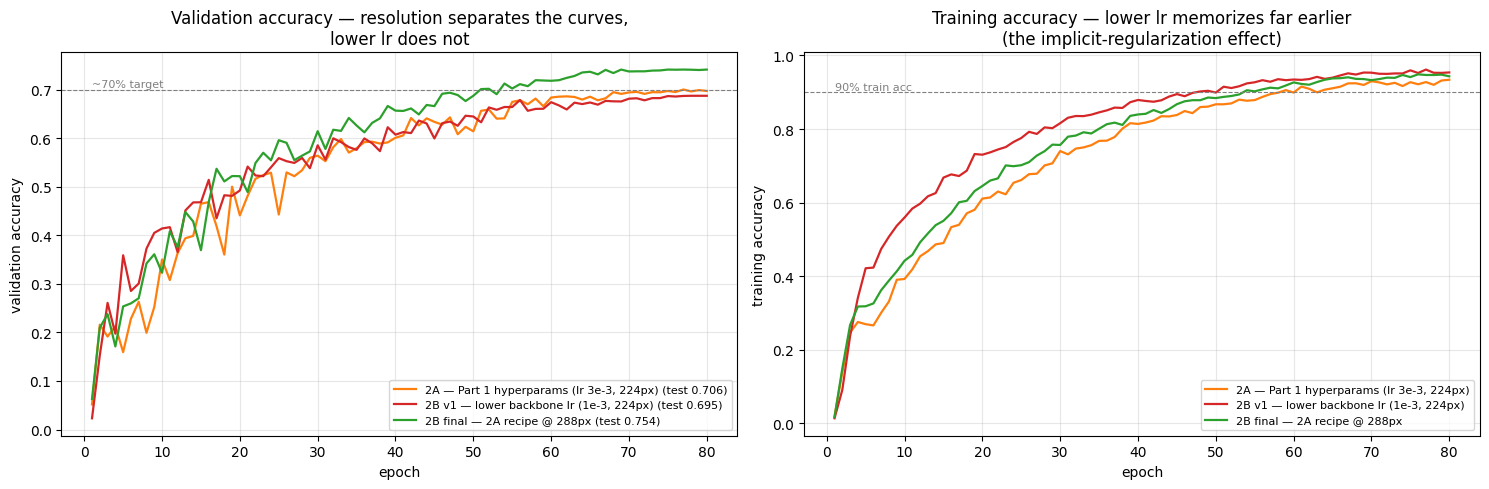

     2A — Part 1 hyperparams (lr 3e-3, 224px) | train acc ≥ 90% at epoch 59
      2B v1 — lower backbone lr (1e-3, 224px) | train acc ≥ 90% at epoch 48
                 2B final — 2A recipe @ 288px | train acc ≥ 90% at epoch 54


In [44]:
P2_RUNS = {
    "part2a_resnet18_samehp": ("2A — Part 1 hyperparams (lr 3e-3, 224px)", "tab:orange"),
    "part2b_resnet18_tuned":  ("2B v1 — lower backbone lr (1e-3, 224px)", "tab:red"),
    "part2b_resnet18_hires":  ("2B final — 2A recipe @ 288px", "tab:green"),
}
P2_RUNS = {k: v for k, v in P2_RUNS.items() if k in RESULTS}  # keep only available runs

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for key, (label, color) in P2_RUNS.items():
    hist = RESULTS[key][1]
    ep = range(1, len(hist["val_acc"]) + 1)
    axes[0].plot(ep, hist["val_acc"], label=f"{label} (test {TEST_ACC[key]:.3f})",
                 color=color, linewidth=1.6)
    axes[1].plot(ep, hist["train_acc"], label=label, color=color, linewidth=1.6)

# Left: validation accuracy
axes[0].axhline(0.70, color="gray", linestyle="--", linewidth=0.8)
axes[0].text(1, 0.705, "~70% target", fontsize=8, color="gray")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Validation accuracy — resolution separates the curves,\nlower lr does not")
axes[0].legend(fontsize=8, loc="lower right"); axes[0].grid(alpha=0.3)

# Right: training accuracy
axes[1].axhline(0.90, color="gray", linestyle="--", linewidth=0.8)
axes[1].text(1, 0.905, "90% train acc", fontsize=8, color="gray")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("training accuracy")
axes[1].set_title("Training accuracy — lower lr memorizes far earlier\n(the implicit-regularization effect)")
axes[1].legend(fontsize=8, loc="lower right"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Epoch at which each run first crosses 90% training accuracy
for key, (label, _) in P2_RUNS.items():
    ta = RESULTS[key][1]["train_acc"]
    cross = next((i + 1 for i, a in enumerate(ta) if a >= 0.90), None)
    print(f"{label:>45s} | train acc ≥ 90% at epoch {cross}")

## 4. Final comparison

We compare Part 1 and Part 2 test accuracy results.

,best val acc,test acc,Δ test vs 2A
run,,,
Part 1 — custom CNN from scratch (224px),0.4995,0.5044,-0.2013
"Part 2A — ResNet-18, Part 1 hyperparams (224px)",0.7003,0.7057,0.0000
Part 2B v1 — lower backbone lr (224px),0.6874,0.6949,-0.0108
Part 2B final — 2A recipe @ 288px,0.7414,0.7537,0.0480


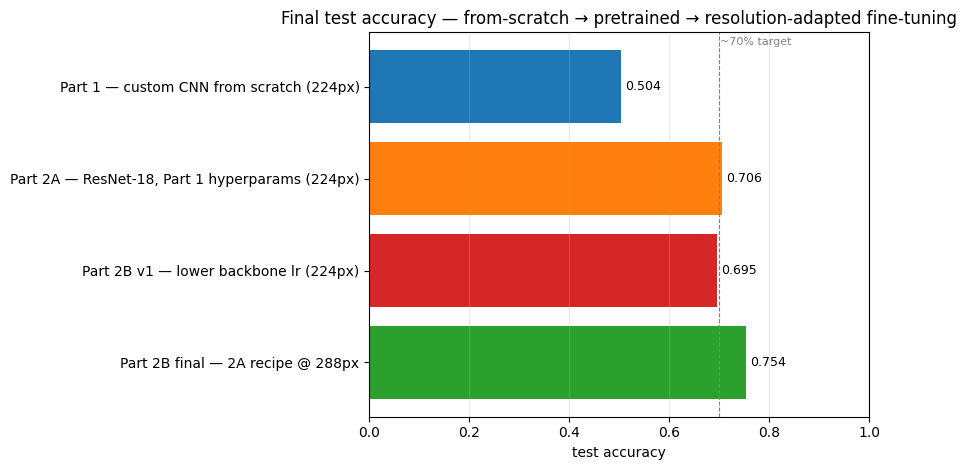

Pretraining gain (Part 1 → 2A): +0.2013
Lower-lr attempt (2A → 2B v1): -0.0108
Resolution change (2A → 2B final): +0.0480


In [46]:
FINAL_RUNS = {
    "part1_best":             "Part 1 — custom CNN from scratch (224px)",
    "part2a_resnet18_samehp": "Part 2A — ResNet-18, Part 1 hyperparams (224px)",
    "part2b_resnet18_tuned":  "Part 2B v1 — lower backbone lr (224px)",
    "part2b_resnet18_hires":  "Part 2B final — 2A recipe @ 288px",
}
FINAL_RUNS = {k: v for k, v in FINAL_RUNS.items() if k in RESULTS}

ref_2a = TEST_ACC["part2a_resnet18_samehp"]
df_final = pd.DataFrame([
    {
        "run": label,
        "best val acc": max(RESULTS[key][1]["val_acc"]),
        "test acc": TEST_ACC[key],
        "Δ test vs 2A": TEST_ACC[key] - ref_2a,
    }
    for key, label in FINAL_RUNS.items()
]).set_index("run").round(4)
display(df_final)

fig, ax = plt.subplots(figsize=(9, 0.9 * len(FINAL_RUNS) + 1.2))
labels = list(FINAL_RUNS.values())
accs = [TEST_ACC[k] for k in FINAL_RUNS]
colors = ["tab:blue", "tab:orange", "tab:red", "tab:green"][:len(labels)]
bars = ax.barh(labels, accs, color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(0.70, color="gray", linestyle="--", linewidth=0.8)
ax.text(0.701, -0.45, "~70% target", fontsize=8, color="gray")
ax.set_xlim(0, 1); ax.set_xlabel("test accuracy")
ax.set_title("Final test accuracy — from-scratch → pretrained → resolution-adapted fine-tuning")
ax.invert_yaxis()  # top-to-bottom in narrative order
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print(f"Pretraining gain (Part 1 → 2A): {TEST_ACC['part2a_resnet18_samehp'] - TEST_ACC['part1_best']:+.4f}")
print(f"Lower-lr attempt (2A → 2B v1): {TEST_ACC['part2b_resnet18_tuned'] - ref_2a:+.4f}")
print(f"Resolution change (2A → 2B final): {TEST_ACC['part2b_resnet18_hires'] - ref_2a:+.4f}")

## 5. Conclusions

In conclusion, we reached **50.4%** test accuracy with a CNN trained from scratch
(Part 1) and **75.4%** by fine-tuning a pretrained ResNet-18 (Part 2), both above their targets.

* **Part 1.** The 80-epoch ablation study revealed a two-tier structure among the design choices we made for our residual CNN: *optimization enablers*, BatchNorm (Δ -31.4) and residual connections (Δ -19.1), are the difference between a working and a failing model. Augmentation in particular trades convergence speed for a higher accuracy ceiling.

* **Part 2.** Pretraining dominates as expected: the unchanged Part 1 recipe already scored **70.6%** (+20.1 over from-scratch). The remedy for its early feature damage, i.e. lower backbone learning rates, removed the instability but *reduced* accuracy. With optimization thus shown to be saturated, the binding constraint was **input resolution**: keeping the 2A recipe and raising the input size to 288 yielded **75.4%** (+4.8), with a smaller generalization gap despite the unchanged regularization.